# Varying the Prompt: Effect on Accuracy

In [1]:
#%%
%load_ext autoreload
%autoreload 2

In [2]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import torch
import pandas as pd
import numpy as np
from functools import partial
from pathlib import Path
import logging

from monoculture.analysis.setup import variations
from monoculture.analysis.utils import (
    key_to_model,
    get_size_and_it,
    load_model_outputs_same_prompt,
    get_metric,
    create_result_df,
    load_task_data,
    load_risk_scores,
    prettify_model_name,
)
from monoculture.analysis.metrics import (
    pairwise_agreement_at_random,
    matrix_pairwise_evals,
    pairwise_agreement_at_random,
    observed_agreement_wrapper,
)


from monoculture.analysis.plotting import plot_agreement_lineplot

In [99]:
plot_config_file = "./results/.matplotlibrc"
plt.rcParams.update(mpl.rc_params_from_file(fname=plot_config_file))
# from seaborn import color_palette
# colors = ['#E69F00', '#56B4E9', '#009E73', '#F0E442', '#0072B2', '#D55E00', '#CC79A7', '#000000', ]
# #color_palette("colorblind")
# plt.rcParams['axes.prop_cycle'] = plt.cycler(color=colors)

TASKS = ["ACSIncome"]
print("tasks", TASKS)
MODELS = [
    "Qwen--Qwen2.5-7B-Instruct",
    "Qwen--Qwen2.5-72B-Instruct",
    "meta-llama--Meta-Llama-3-8B-Instruct",
    "meta-llama--Meta-Llama-3.3-70B-Instruct",
]

subfolder = [
    "folktexts/0-variations",
    "folktexts/10-variations",
]

RESULTS_ROOT_DIR = Path("./results/")
results_df_path = RESULTS_ROOT_DIR / "overview_results_variations.csv"
FIGURES_ROOT_DIR = RESULTS_ROOT_DIR / "figures/vary-prompt/"
FIGURES_PAPER_DIR = RESULTS_ROOT_DIR / "figures/paper/vary-prompt/"

tasks ['ACSIncome']


In [4]:
data = None
variations

{'feature_order': ['default', 'rand 1', 'rand 2', 'rand 3', ' reversed'],
 'format': ['bullet', 'text', 'comma'],
 'connector': ['is', '=', ':'],
 'granularity': ['original', 'low']}

## Load available models and variations

In [5]:
load_df = False
df = (
    pd.read_csv(results_df_path)
    if load_df
    else create_result_df(
        RESULTS_ROOT_DIR, subfolders=subfolder, tasks=TASKS, save_path=results_df_path
    )
)

Shape of df:  (1066, 14)
Saving dataframe to results/overview_results_variations.csv


## Load predictions

In [6]:
num_shots = 0
threshold_fitted = 1

df = pd.read_csv(results_df_path)
# restrict to zero-shot and same prompt style
df_vary_prompt = df[
    (df["num_shots"] == num_shots) & (df["threshold_fitted"] == threshold_fitted)
]
print(df_vary_prompt.shape)
print(df_vary_prompt["model"].unique())
df_vary_prompt.head()

(573, 14)
['Qwen--Qwen2.5-72B-Instruct' 'meta-llama--Meta-Llama-3-8B-Instruct'
 'Qwen--Qwen2.5-7B-Instruct' 'Qwen--Qwen2-7B-Instruct' 'Qwen--Qwen2.5-72B'
 'mistralai--Mistral-Small-24B-Instruct-2501'
 'meta-llama--Meta-Llama-3.3-70B-Instruct']


,task,model,is_inst,threshold_fitted,threshold,accuracy,bench_hash,num_shots,prompt_format,prompt_connector,prompt_granularity,prompt_feature_order,eval_results_path,predictions_path
0,ACSIncome,Qwen--Qwen2.5-72B-Instruct,1,1,0.164835,0.761706,175002779,0,text,=,low,reversed,results/folktexts/0-variations/model-Qwen--Qwe...,results/folktexts/0-variations/model-Qwen--Qwe...
1,ACSIncome,Qwen--Qwen2.5-72B-Instruct,1,1,0.148014,0.776888,1344084919,0,bullet,is,original,reversed,results/folktexts/0-variations/model-Qwen--Qwe...,results/folktexts/0-variations/model-Qwen--Qwe...
2,ACSIncome,Qwen--Qwen2.5-72B-Instruct,1,1,0.003172,0.766957,3156286684,0,text,is,original,default,results/folktexts/0-variations/model-Qwen--Qwe...,results/folktexts/0-variations/model-Qwen--Qwe...
3,ACSIncome,Qwen--Qwen2.5-72B-Instruct,1,1,0.003183,0.772761,2985942201,0,bullet,:,original,default,results/folktexts/0-variations/model-Qwen--Qwe...,results/folktexts/0-variations/model-Qwen--Qwe...
4,ACSIncome,Qwen--Qwen2.5-72B-Instruct,1,1,0.007574,0.779946,1338756957,0,bullet,is,original,default,results/folktexts/0-variations/model-Qwen--Qwe...,results/folktexts/0-variations/model-Qwen--Qwe...


In [7]:
print(df_vary_prompt.shape)
try:
    assert set(TASKS).issubset(
        set(df_vary_prompt["task"].unique())
    ), f"Results for all tasks to be analysed have to be available, available are: {list(df_vary_prompt['task'].unique())} "
except AssertionError:
    logging.warning("Reduced TASKS to available tasks.")
    TASKS = list(df_vary_prompt["task"].unique())
try:
    assert set(MODELS).issubset(
        set(df_vary_prompt["model"].unique())
    ), f"Results for all tasks to be analysed have to be available, available are: {list(df_vary_prompt['model'].unique())} "
except AssertionError:
    logging.warning("Reduced MODELS to available models.")
    MODELS = list(df_vary_prompt["model"].unique())

TASKS, MODELS

(573, 14)


(['ACSIncome'],
 ['Qwen--Qwen2.5-7B-Instruct',
  'Qwen--Qwen2.5-72B-Instruct',
  'meta-llama--Meta-Llama-3-8B-Instruct',
  'meta-llama--Meta-Llama-3.3-70B-Instruct'])

In [8]:
risk_scores = (
    df_vary_prompt["predictions_path"]
    .apply(load_risk_scores)
    .apply(lambda x: x.squeeze())
    .add_prefix("score_")
)
risk_scores.head()
df_with_riskscores = pd.concat([df_vary_prompt, risk_scores], axis=1)
print(df_with_riskscores.shape)
display(df_with_riskscores.head())

df_with_predictions = df_with_riskscores.copy()
model_wise_thresholds = df_with_predictions["threshold"]
df_with_predictions.update(
    df_with_predictions.filter(like="score_").apply(
        lambda col: (col >= model_wise_thresholds).astype(int)
    )
)

(573, 166464)


,task,model,is_inst,threshold_fitted,threshold,accuracy,bench_hash,num_shots,prompt_format,prompt_connector,...,score_944636,score_675237,score_926337,score_2205318,score_3164791,score_43637,score_2494279,score_2989522,score_688458,score_1778641
0,ACSIncome,Qwen--Qwen2.5-72B-Instruct,1,1,0.164835,0.761706,175002779,0,text,=,...,0.817610,0.000203,0.999445,0.067620,0.004594,0.593750,0.000432,0.000710,0.998831,0.992433
1,ACSIncome,Qwen--Qwen2.5-72B-Instruct,1,1,0.148014,0.776888,1344084919,0,bullet,is,...,0.106689,0.000140,0.999860,0.018028,0.984146,0.851960,0.000204,0.000159,0.997210,0.182796
2,ACSIncome,Qwen--Qwen2.5-72B-Instruct,1,1,0.003172,0.766957,3156286684,0,text,is,...,0.001699,0.000066,0.999821,0.000380,0.852130,0.561404,0.000123,0.000159,0.998678,0.133127
3,ACSIncome,Qwen--Qwen2.5-72B-Instruct,1,1,0.003183,0.772761,2985942201,0,bullet,:,...,0.000488,0.000066,0.999877,0.000488,0.817727,0.777349,0.000096,0.000096,0.999089,0.042092
4,ACSIncome,Qwen--Qwen2.5-72B-Instruct,1,1,0.007574,0.779946,1338756957,0,bullet,is,...,0.000908,0.000058,0.999891,0.000553,0.852137,0.678851,0.000096,0.000109,0.998967,0.182320


In [23]:
mask = df_with_predictions['task']=='ACSIncome'
top_acc = df_with_predictions[mask]['accuracy'].max()
eps = 0.05
mask &= df_with_predictions['accuracy']>= top_acc - eps
df_with_predictions[mask].sort_values(by='accuracy', ascending=False)

,task,model,is_inst,threshold_fitted,threshold,accuracy,bench_hash,num_shots,prompt_format,prompt_connector,...,score_944636,score_675237,score_926337,score_2205318,score_3164791,score_43637,score_2494279,score_2989522,score_688458,score_1778641
597,ACSIncome,meta-llama--Meta-Llama-3.3-70B-Instruct,1,1,0.999411,0.789462,3212939787,0,bullet,is,...,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0
474,ACSIncome,Qwen--Qwen2.5-72B,0,1,0.438235,0.787972,903894723,0,text,is,...,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0
418,ACSIncome,Qwen--Qwen2.5-72B,0,1,0.436950,0.785479,162675388,0,text,=,...,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0
751,ACSIncome,meta-llama--Meta-Llama-3.3-70B-Instruct,1,1,0.999541,0.785095,2982431102,0,bullet,is,...,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0
478,ACSIncome,Qwen--Qwen2.5-72B,0,1,0.348554,0.784536,2727194018,0,bullet,is,...,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
506,ACSIncome,mistralai--Mistral-Small-24B-Instruct-2501,1,1,0.730667,0.739946,1674786523,0,comma,:,...,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0
540,ACSIncome,mistralai--Mistral-Small-24B-Instruct-2501,1,1,0.904762,0.739832,1244911466,0,comma,:,...,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0
412,ACSIncome,Qwen--Qwen2-7B-Instruct,1,1,0.407115,0.739796,3103135745,0,bullet,:,...,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0
315,ACSIncome,Qwen--Qwen2.5-7B-Instruct,1,1,0.053448,0.739760,2097281108,0,comma,=,...,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0


## Aggregate Level: Check accuracy

In [9]:
models_to_plot = MODELS
models_to_plot = sorted(models_to_plot, key=get_size_and_it)

### Scatter Plot: Fix one variation, average over all others

performance-0-shot-fix-one-avg-rest_tresh_fitted.png


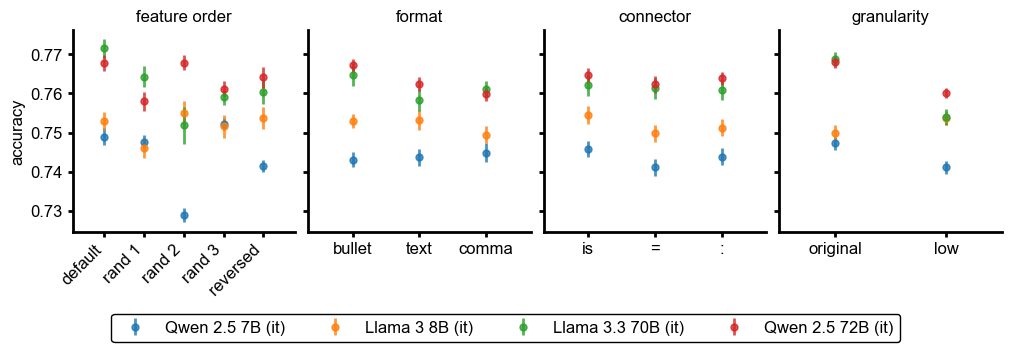

In [10]:
fig, axs = plt.subplots(
    1,
    len(variations.keys()),
    figsize=(10, 3),
    constrained_layout=True,
    sharey=True,
    sharex="col",
)

for i, (v, vary_values) in enumerate(variations.items()):
    for model in models_to_plot:
        num_vals = len(vary_values)
        mean_per_val = []
        std_err_per_val = []
        for val in vary_values:
            accs = df_vary_prompt[
                (df_vary_prompt["model"] == model)
                & (df_vary_prompt["prompt_" + v] == val)
            ]["accuracy"].values
            mean_per_val.append(accs.mean())
            std_err_per_val.append(accs.std() / np.sqrt(len(accs)))

        axs[i].errorbar(
            np.arange(num_vals),
            mean_per_val,
            yerr=std_err_per_val,
            fmt="o",
            alpha=0.8,
            label=prettify_model_name(key_to_model(model)),
        )
        # axs[i,i].errorbar(x=np.arange(len(variations[vari])), y=mean_per_val, yerr=stderr_per_val, fmt='o', color='black')
    axs[i].set_xticks(
        np.arange(num_vals),
        vary_values,
        rotation=(0 if v != "feature_order" else 45),
        ha=("center" if v != "feature_order" else "right"),
    )
    axs[i].set_title(v.replace("_", " "))
    axs[i].set_xmargin(1 / num_vals)

    axs[0].set_ylabel("accuracy")

# legend
handles, labels = axs[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=len(labels),
    bbox_to_anchor=(0.5, -0.15),
    frameon=True,  # show box
    framealpha=1.0,  # opacity of box
    edgecolor="black",  # border color
    fancybox=True,
)  # rounded corners)

file_name = "".join(
    [
        f"performance-{num_shots}-shot-fix-one-avg-rest",
        "_tresh_fitted" if threshold_fitted == 1 else "",
        ".png",
    ]
)
plt.savefig(FIGURES_ROOT_DIR / file_name)
print(file_name)

plt.show()

### Matrix Plot: accuracy for different pairs of variations
Fix two variations, average over the rest to see mixed effects.

Qwen--Qwen2.5-7B-Instruct
accuracy-matrix-0-shot-model-Qwen--Qwen2.5-7B-Instruct_tresh_fitted.png


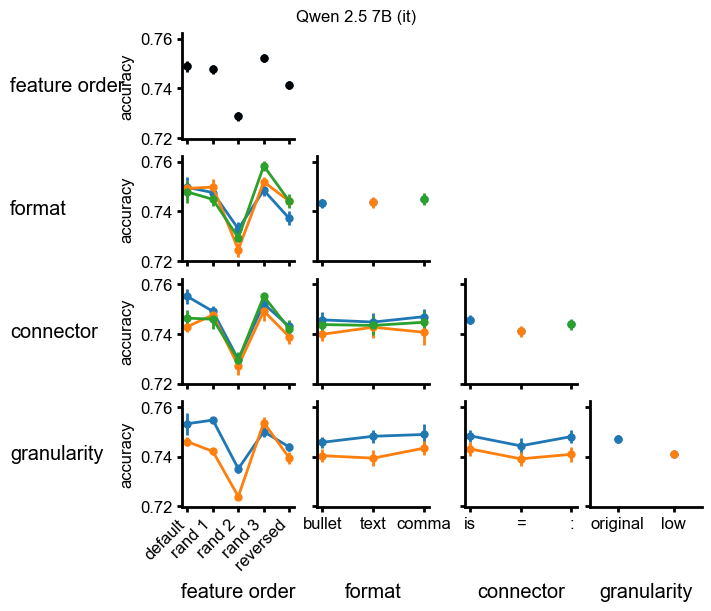

meta-llama--Meta-Llama-3-8B-Instruct
accuracy-matrix-0-shot-model-meta-llama--Meta-Llama-3-8B-Instruct_tresh_fitted.png


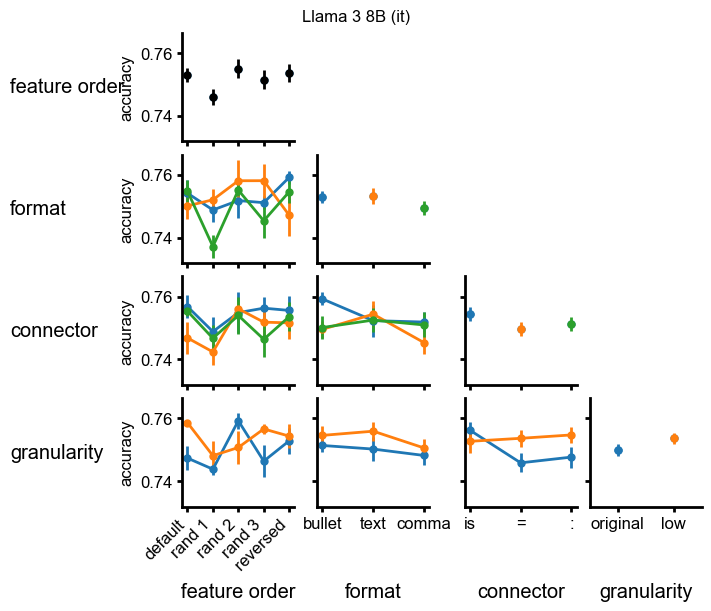

meta-llama--Meta-Llama-3.3-70B-Instruct
accuracy-matrix-0-shot-model-meta-llama--Meta-Llama-3.3-70B-Instruct_tresh_fitted.png


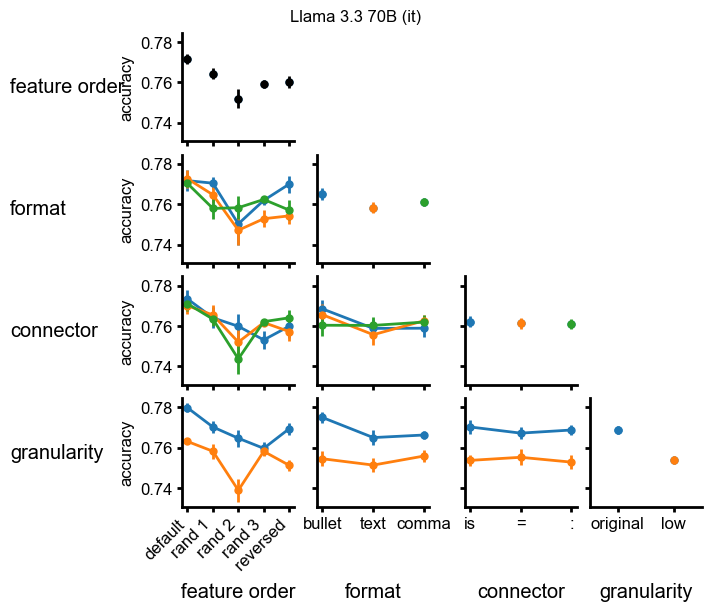

Qwen--Qwen2.5-72B-Instruct
accuracy-matrix-0-shot-model-Qwen--Qwen2.5-72B-Instruct_tresh_fitted.png


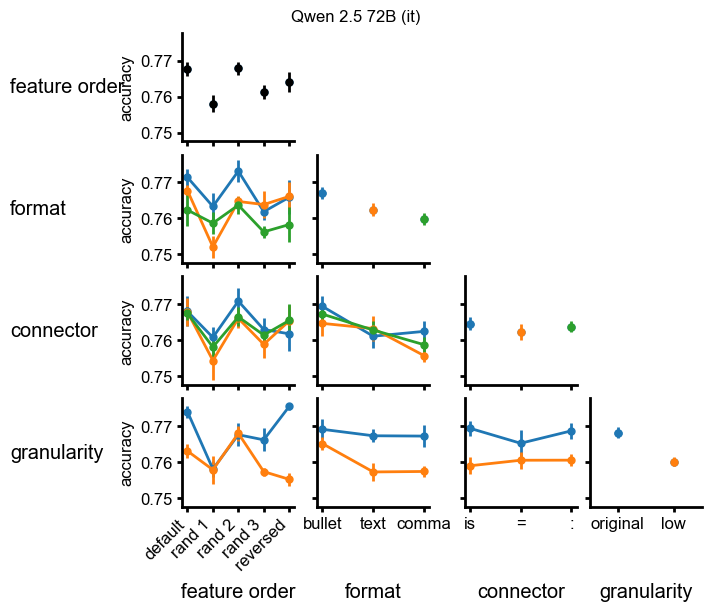

In [11]:
# lower triangular
for model in sorted(models_to_plot, key=get_size_and_it):
    print(model)
    fig, axs = plt.subplots(
        len(variations.keys()),
        len(variations.keys()),
        figsize=(7, 6),
        constrained_layout=True,
        sharey=True,
        sharex="col",
    )
    fig.suptitle(prettify_model_name(key_to_model(model)))
    for i, vari in enumerate(variations.keys()):
        for j, varj in enumerate(variations.keys()):
            if i == j:
                mean_per_val = []
                stderr_per_val = []
                for val in variations[vari]:
                    accs = df_vary_prompt[
                        (df_vary_prompt["model"] == model)
                        & (df_vary_prompt["prompt_" + vari] == val)
                    ]["accuracy"].values
                    mean_per_val.append(accs.mean())
                    stderr_per_val.append(accs.std() / np.sqrt(len(accs)))
                axs[i, i].scatter(np.arange(len(variations[vari])), mean_per_val)
                if i > 0:  #!= len(variations.keys())-1:
                    colors = [f"C{i}" for i in range(len(mean_per_val))]
                    for idx, (x_val, y_val, yerr_val) in enumerate(
                        zip(np.arange(len(mean_per_val)), mean_per_val, stderr_per_val)
                    ):
                        axs[i, i].errorbar(
                            x=x_val, y=y_val, yerr=yerr_val, fmt="o", color=colors[idx]
                        )
                else:
                    axs[i, i].errorbar(
                        x=np.arange(len(variations[vari])),
                        y=mean_per_val,
                        yerr=stderr_per_val,
                        fmt="o",
                        color="black",
                    )
            elif i > j:
                for vali in variations[vari]:
                    mean_per_valj = []
                    stderr_per_valj = []
                    for valj in variations[varj]:
                        accs = df_vary_prompt[
                            (df_vary_prompt["model"] == model)
                            & (df_vary_prompt["prompt_" + vari] == vali)
                            & (df_vary_prompt["prompt_" + varj] == valj)
                        ]["accuracy"].values
                        mean_per_valj.append(accs.mean())
                        stderr_per_valj.append(accs.std() / np.sqrt(len(accs)))
                    axs[i, j].errorbar(
                        x=np.arange(len(variations[varj])),
                        y=mean_per_valj,
                        yerr=stderr_per_valj,
                        fmt="-o",
                        label=f"{vari}={vali}",
                    )
            else:
                axs[i, j].axis("off")
            if len(variations[varj]) <= 2:
                axs[i, j].set_xmargin(0.5)
            if i == len(variations.keys()) - 1:
                axs[i, j].set_xticks(
                    np.arange(len(variations[varj])),
                    variations[varj],
                    rotation=0 if varj != "feature_order" else 45,
                    ha="center" if varj != "feature_order" else "right",
                )
                axs[i, j].set_xlabel(varj.replace("_", " "), size="large")
            if j == 0:
                axs[i, j].set_ylabel("accuracy")
                axs[i, j].annotate(
                    vari.replace("_", " "),
                    xy=(0, 0.5),
                    xytext=(-axs[i, j].yaxis.labelpad - 75, 0),
                    xycoords=axs[i, j].yaxis.label,
                    textcoords="offset points",
                    size="large",
                    ha="left",
                    va="center",
                )

    fig.align_xlabels()

    file_name = "".join(
        [
            f"accuracy-matrix-{num_shots}-shot-model-{model}",
            "_tresh_fitted" if threshold_fitted == 1 else "",
            ".png",
        ]
    )
    plt.savefig(FIGURES_ROOT_DIR / file_name)
    print(file_name)
    plt.show()

### Bar Plot: Fix one variation, fix others to default

prompt_feature_order 35
Qwen 2.5 7B (it) 	 0.75	0.00
Llama 3 8B (it)  	 0.76	0.00
Llama 3.3 70B (it)	 0.78	0.00
Qwen 2.5 72B (it)	 0.77	0.00
prompt_format 21
Qwen 2.5 7B (it) 	 0.76	0.00
Llama 3 8B (it)  	 0.75	0.01
Llama 3.3 70B (it)	 0.78	0.00
Qwen 2.5 72B (it)	 0.77	0.00
prompt_connector 21
Qwen 2.5 7B (it) 	 0.75	0.01
Llama 3 8B (it)  	 0.75	0.01
Llama 3.3 70B (it)	 0.78	0.00
Qwen 2.5 72B (it)	 0.78	0.00
prompt_granularity 14
Qwen 2.5 7B (it) 	 0.76	0.01
Llama 3 8B (it)  	 0.76	0.00
Llama 3.3 70B (it)	 0.77	0.01
Qwen 2.5 72B (it)	 0.77	0.01


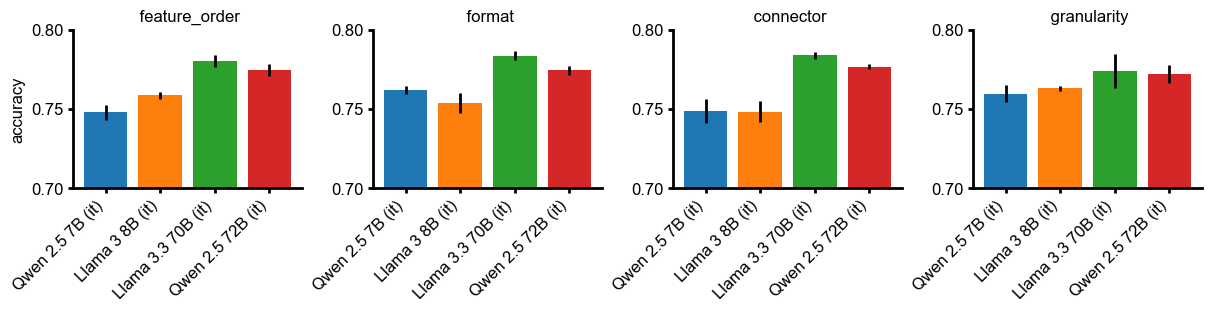

In [12]:
vary_variable = "prompt_feature_order"
default_cond = {
    "prompt_feature_order": variations["feature_order"][0],
    "prompt_format": "bullet",
    "prompt_connector": "is",
    "prompt_granularity": "original",
}

# Plot
fig, axs = plt.subplots(
    1, len(variations.keys()), figsize=(12, 3), constrained_layout=True
)
for v, vary_variable in enumerate(default_cond.keys()):
    df_vary_one = df_vary_prompt.loc[
        list(
            set.intersection(
                *[
                    set(df_vary_prompt[df_vary_prompt[key] == val].index)
                    for key, val in default_cond.items()
                    if key != vary_variable
                ]
            )
        )
    ]
    print(vary_variable, df_vary_one.shape[0])
    for i, model in enumerate(models_to_plot):
        accs = df_vary_one[df_vary_one["model"] == model]["accuracy"].values
        mean = accs.mean()
        stderr = accs.std() / np.sqrt(len(accs))  # or standard error?
        print(
            f"{prettify_model_name(key_to_model(model)):17}\t {mean:.2f}\t{stderr:.2f}"
        )

        axs[v].bar(i, mean, yerr=stderr, label=prettify_model_name(key_to_model(model)))
    axs[v].set_xticks(
        np.arange(len(models_to_plot)),
        [prettify_model_name(key_to_model(model)) for model in models_to_plot],
        rotation=45,
        ha="right",
    )
    axs[v].set_title(vary_variable.replace("prompt_", " "))
    axs[v].set_ylim(0.7, 0.8)
axs[0].set_ylabel("accuracy")

file_name = "".join(
    [
        f"performance-{num_shots}-shot-fix-one-default-rest-barplot",
        "_tresh_fitted" if threshold_fitted == 1 else "",
        ".png",
    ]
)

plt.savefig(FIGURES_ROOT_DIR / file_name)
plt.show()

### Scatter Plot: Fix one variation, others default

prompt_feature_order 35
Qwen 2.5 7B (it) 	 0.75	0.005	0.031
Llama 3 8B (it)  	 0.76	0.002	0.015
Llama 3.3 70B (it)	 0.78	0.004	0.023
Qwen 2.5 72B (it)	 0.77	0.004	0.024
prompt_format 21
Qwen 2.5 7B (it) 	 0.76	0.003	0.011
Llama 3 8B (it)  	 0.75	0.006	0.024
Llama 3.3 70B (it)	 0.78	0.003	0.012
Qwen 2.5 72B (it)	 0.77	0.003	0.013
prompt_connector 21
Qwen 2.5 7B (it) 	 0.75	0.008	0.029
Llama 3 8B (it)  	 0.75	0.007	0.028
Llama 3.3 70B (it)	 0.78	0.002	0.010
Qwen 2.5 72B (it)	 0.78	0.002	0.007
prompt_granularity 14
Qwen 2.5 7B (it) 	 0.76	0.005	0.015
Llama 3 8B (it)  	 0.76	0.002	0.004
Llama 3.3 70B (it)	 0.77	0.011	0.031
Qwen 2.5 72B (it)	 0.77	0.006	0.016
performance-0-shot-fix-one-default-rest-scatter_tresh_fitted


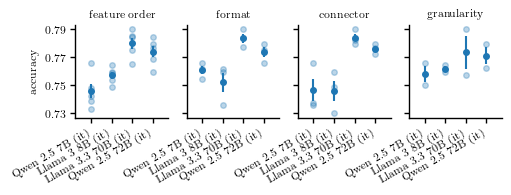

In [100]:
eps = 0.05
max_acc_acsincome = 0.789462
plot_all = False
default_cond = {
    "prompt_feature_order": variations["feature_order"][0],
    "prompt_format": "bullet",
    "prompt_connector": "is",
    "prompt_granularity": "original",
}
# select all individuals where some key is the default value
all_default_accs = df_vary_prompt.loc[
    list(
        set.intersection(
            *[
                set(df_vary_prompt[df_vary_prompt[key] == val].index)
                for key, val in default_cond.items()
            ]
        )
    )
][["model", "accuracy"]]

default_width = plt.rcParams['figure.figsize'][0]
# Set custom height
custom_height = 1.2 #plt.rcParams['figure.figsize'][1]


# Plot
fig, axs = plt.subplots(
    1,
    len(variations.keys())+int(plot_all),
    figsize=(default_width, custom_height),
    # , constrained_layout=True,
    sharey=True
)

y_max = 0
y_min = 1
for v, vary_variable in enumerate(list(default_cond.keys()) + (['all combinations'] if plot_all else [])):
    # select all individuals where all but one (vary_variable) are set to the default value
    df_vary_one = df_vary_prompt.loc[
        list(
            set.intersection(
                *[
                    set(df_vary_prompt[df_vary_prompt[key] == val].index)
                    for key, val in default_cond.items()
                    if key != vary_variable
                ]
            )
        )
    ]
    alpha=0.3
    if vary_variable == 'all combinations':
        #mask = df_vary_prompt['accuracy'] >= max_acc_acsincome - eps
        df_vary_one = df_vary_prompt#[mask]
        alpha=0.1

    print(vary_variable, df_vary_one.shape[0])
    # axs[v].hlines([max_acc_acsincome, max_acc_acsincome-eps], xmin=0, xmax=len(models_to_plot)-1, color='lightgray', linestyle='dashed', zorder=-2, linewidth=1)
    
    for i, model in enumerate(models_to_plot):
        accs = df_vary_one[df_vary_one["model"] == model]["accuracy"].values
        # display(df_vary_one[df_vary_one["model"] == model]["accuracy"].values)
        mean = accs.mean()
        stderr = accs.std() / np.sqrt(len(accs))  # or standard error?
        print(
            f"{prettify_model_name(key_to_model(model)):17}\t {mean:.2f}\t{stderr:.3f}\t{accs.max()-accs.min():.3f}"
        )
        if accs.max() > y_max:
            y_max = accs.max()
        if accs.min() < y_min:
            y_min = accs.min()

        default_acc = all_default_accs[all_default_accs["model"] == model][
            "accuracy"
        ].item()
        # axs[v].scatter(i, default_acc, color="black", marker="x", label="default")
        axs[v].errorbar(i, mean, yerr=stderr, ls="None", color="C0", label="mean")
        axs[v].scatter(i, mean, color="C0")
        axs[v].scatter([i] * len(accs), accs, color="C0", alpha=alpha)
        axs[v].set_xmargin(1 / len(models_to_plot))
    axs[v].set_xticks(
        np.arange(len(models_to_plot)),
        [prettify_model_name(key_to_model(model)) for model in models_to_plot],
        rotation=30,
        ha="right",
        va='top'
    )


    axs[v].set_title(vary_variable.replace("prompt_", " ").replace("_", " "))
axs[0].set_ylabel("accuracy")
yticks = np.linspace(y_min, y_max, num=4)
axs[0].set_yticks(yticks, [f"{tick:.2}" for tick in yticks])


file_name = "".join(
    [
        f"performance-{num_shots}-shot-fix-one-default-rest-scatter",
        "_tresh_fitted" if threshold_fitted == 1 else "",
    ]
)

for ending in [".png", ".pdf"]:
    plt.savefig(FIGURES_ROOT_DIR / (file_name + ending))
    plt.savefig(FIGURES_PAPER_DIR / (file_name + ending))
print(file_name)

plt.show()

In [14]:
df_vary_one = df_vary_prompt.loc[
    list(
        set.intersection(
            *[
                set(df_vary_prompt[df_vary_prompt[key] == val].index)
                for key, val in default_cond.items()
                if key != vary_variable
            ]
        )
    )
]
df_vary_one[df_vary_one["model"] == model]

,task,model,is_inst,threshold_fitted,threshold,accuracy,bench_hash,num_shots,prompt_format,prompt_connector,prompt_granularity,prompt_feature_order,eval_results_path,predictions_path
4,ACSIncome,Qwen--Qwen2.5-72B-Instruct,1,1,0.007574,0.779946,1338756957,0,bullet,is,original,default,results/folktexts/0-variations/model-Qwen--Qwe...,results/folktexts/0-variations/model-Qwen--Qwe...
46,ACSIncome,Qwen--Qwen2.5-72B-Instruct,1,1,0.033094,0.763755,1179024929,0,bullet,is,low,default,results/folktexts/0-variations/model-Qwen--Qwe...,results/folktexts/0-variations/model-Qwen--Qwe...


In [15]:
df_vary_prompt[df_vary_prompt["model"] == model]

,task,model,is_inst,threshold_fitted,threshold,accuracy,bench_hash,num_shots,prompt_format,prompt_connector,prompt_granularity,prompt_feature_order,eval_results_path,predictions_path
0,ACSIncome,Qwen--Qwen2.5-72B-Instruct,1,1,0.164835,0.761706,175002779,0,text,=,low,reversed,results/folktexts/0-variations/model-Qwen--Qwe...,results/folktexts/0-variations/model-Qwen--Qwe...
1,ACSIncome,Qwen--Qwen2.5-72B-Instruct,1,1,0.148014,0.776888,1344084919,0,bullet,is,original,reversed,results/folktexts/0-variations/model-Qwen--Qwe...,results/folktexts/0-variations/model-Qwen--Qwe...
2,ACSIncome,Qwen--Qwen2.5-72B-Instruct,1,1,0.003172,0.766957,3156286684,0,text,is,original,default,results/folktexts/0-variations/model-Qwen--Qwe...,results/folktexts/0-variations/model-Qwen--Qwe...
3,ACSIncome,Qwen--Qwen2.5-72B-Instruct,1,1,0.003183,0.772761,2985942201,0,bullet,:,original,default,results/folktexts/0-variations/model-Qwen--Qwe...,results/folktexts/0-variations/model-Qwen--Qwe...
4,ACSIncome,Qwen--Qwen2.5-72B-Instruct,1,1,0.007574,0.779946,1338756957,0,bullet,is,original,default,results/folktexts/0-variations/model-Qwen--Qwe...,results/folktexts/0-variations/model-Qwen--Qwe...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
72,ACSIncome,Qwen--Qwen2.5-72B-Instruct,1,1,0.037262,0.755392,3835238897,0,comma,=,low,default,results/folktexts/0-variations/model-Qwen--Qwe...,results/folktexts/0-variations/model-Qwen--Qwe...
73,ACSIncome,Qwen--Qwen2.5-72B-Instruct,1,1,0.060156,0.753343,2176935243,0,comma,=,low,reversed,results/folktexts/0-variations/model-Qwen--Qwe...,results/folktexts/0-variations/model-Qwen--Qwe...
74,ACSIncome,Qwen--Qwen2.5-72B-Instruct,1,1,0.012454,0.755176,2756884914,0,text,=,low,rand 3,results/folktexts/0-variations/model-Qwen--Qwe...,results/folktexts/0-variations/model-Qwen--Qwe...
75,ACSIncome,Qwen--Qwen2.5-72B-Instruct,1,1,0.244386,0.776642,1602886547,0,text,=,original,reversed,results/folktexts/0-variations/model-Qwen--Qwe...,results/folktexts/0-variations/model-Qwen--Qwe...


In [16]:
(
    df_vary_prompt[df_vary_prompt["model"] == model]["accuracy"].values.max()
    - df_vary_prompt[df_vary_prompt["model"] == model]["accuracy"].values.min()
)

0.04555722439170917